# Noise and saturation

`wcc_sim` applies the `wcc_etc` noise model exactly: sky + dark, per-frame full-well /
ADC saturation, Poisson noise, read noise, and digitization to ADU. This notebook walks
through it with a controlled star field: a brightness ladder from G = 6 to 16 at
+2 waves defocus.

**Requirements:** the `py313` conda env kernel. Fully offline (synthetic catalog).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
import wcc_sim

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_etc {wcc_etc.__version__}')

wcc_sim 0.1.0 | wcc_etc 0.6.0


## 1. A brightness ladder

Six stars, G = 6 to 16, placed along a column at x = 400 so the left half of the frame
stays star-free for background statistics. Coordinates are generated through the same
TAN WCS the simulator will build.

In [2]:
from astropy.table import Table
from wcc_sim import simulate_field
from wcc_sim.detectors import get_geometry
from wcc_sim.wcsutil import build_wcs

RA0, DEC0 = 150.1, 2.2
SHAPE = (512, 512)
EXPTIME = 90.0
GMAGS = np.array([6.0, 8.0, 10.0, 12.0, 14.0, 16.0])

g = get_geometry('zwo:r')
w = build_wcs(RA0, DEC0, g.plate_scale_mas, 0.0, SHAPE)
ys = np.linspace(60, 460, len(GMAGS))
ras, decs = w.pixel_to_world_values(np.full_like(ys, 400.0), ys)
cat = Table({
    'source_id': np.arange(len(GMAGS)), 'ra': ras, 'dec': decs,
    'phot_g_mean_mag': GMAGS,
    'phot_bp_mean_mag': np.full(len(GMAGS), np.nan),  # -> G2V
    'phot_rp_mean_mag': np.full(len(GMAGS), np.nan),
})

field = simulate_field(RA0, DEC0, sensorfilter='zwo:r', focus=2, exptime=EXPTIME,
                       seed=42, catalog=cat, shape=SHAPE)
p = field.params
print(f"sky {p['sky_e_s']:.3f} + dark {p['dark_e_s']:.4f} e-/s/px | "
      f"read noise {p['read_noise']:.2f} e- | gain {p['gain']:.3f} e-/ADU | "
      f"well depth {p['well_depth']} e-")
print(f'saturated pixels: {field.saturation_mask.sum()}')

sky 0.014 + dark 0.0031 e-/s/px | read noise 3.04 e- | gain 0.261 e-/ADU | well depth 16274.929434794496 e-
saturated pixels: 20604


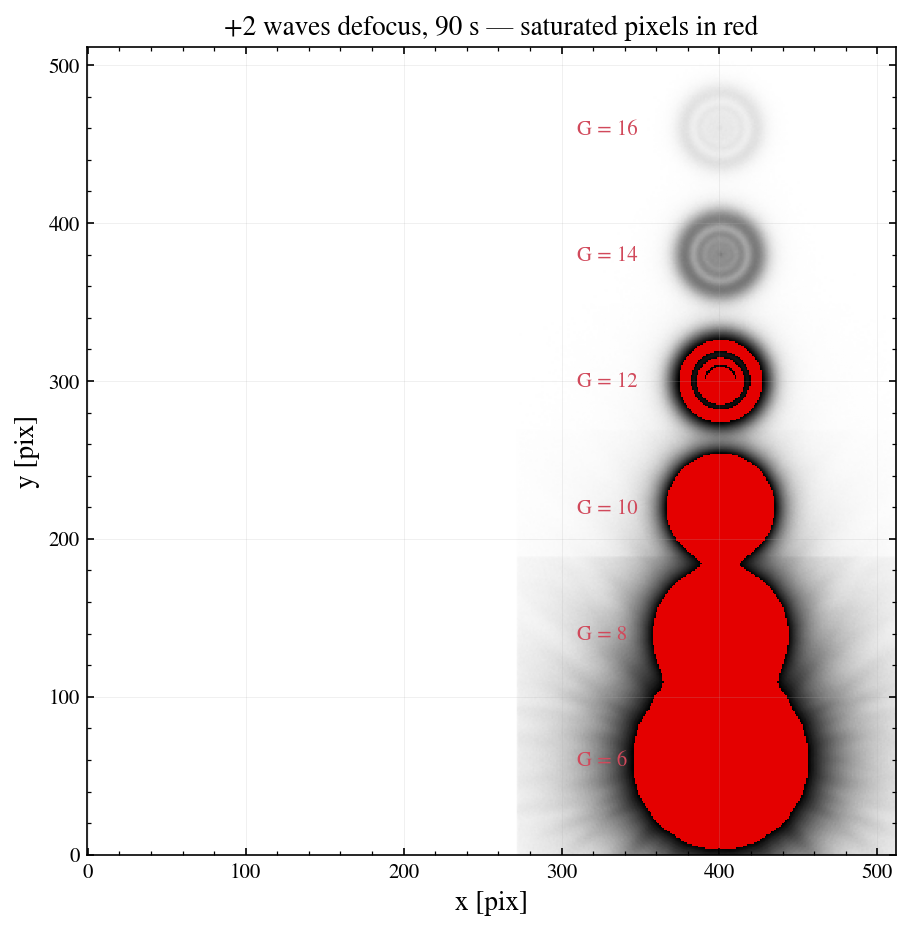

In [3]:
from astropy.visualization import simple_norm

fig, ax = plt.subplots(figsize=(7.5, 7))
img = field.image_adu
ax.imshow(img, origin='lower', cmap='gray_r',
          norm=simple_norm(img, 'asinh', percent=99.5))
sat = np.ma.masked_where(~field.saturation_mask, field.saturation_mask)
ax.imshow(sat, origin='lower', cmap='autumn', alpha=0.9, interpolation='none')
for gmag, y in zip(GMAGS, ys):
    ax.annotate(f'G = {gmag:.0f}', (400, y), xytext=(310, y - 4), color=RED)
ax.set_xlabel('x [pix]'); ax.set_ylabel('y [pix]')
ax.set_title('+2 waves defocus, 90 s — saturated pixels in red')
plt.show()

Note the shape of the saturated regions: the defocused PSF saturates in its bright
*ring* first — for stars near the threshold the central pixel stays below full well.
This is why the per-star `saturated` flag checks a 32 px window
(`wcc_sim.render.star_saturated`), not just the central pixel.

In [4]:
sat_flags = np.asarray(field.catalog['saturated'])
for gmag, flag in zip(GMAGS, sat_flags):
    print(f'G = {gmag:4.1f}  saturated = {bool(flag)}')
assert sat_flags[GMAGS <= 8].all() and not sat_flags[GMAGS >= 14].any()

G =  6.0  saturated = True
G =  8.0  saturated = True
G = 10.0  saturated = True
G = 12.0  saturated = True
G = 14.0  saturated = False
G = 16.0  saturated = False


## 2. The background noise budget

In a star-free region the pixel variance should be Poisson on (sky + dark) × exptime
plus the read-noise variance. Compare the measured standard deviation of `image_e`
(electrons, before digitization) against that expectation.

background level:     1.49 e-  (expected     1.50)
background std:       3.28 e-  (expected     3.28)


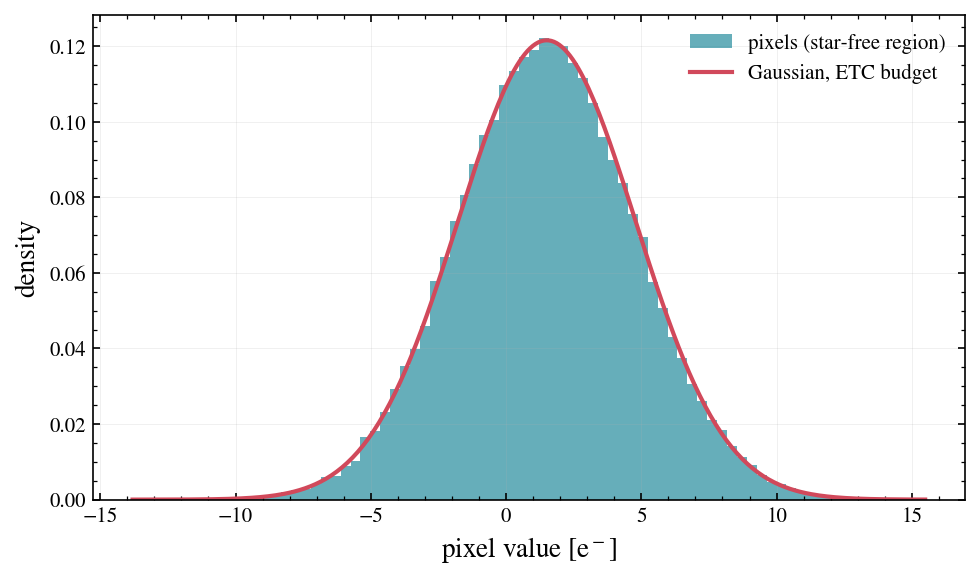

In [5]:
bkg = field.image_e[:, :200]                     # star-free left half
level_e = (p['sky_e_s'] + p['dark_e_s']) * EXPTIME
expected = np.sqrt(level_e + p['read_noise'] ** 2)
measured = bkg.std()
print(f'background level: {bkg.mean():8.2f} e-  (expected {level_e:8.2f})')
print(f'background std:   {measured:8.2f} e-  (expected {expected:8.2f})')
assert abs(measured / expected - 1) < 0.05

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(bkg.ravel(), bins=80, density=True, color=TEAL, alpha=0.6,
        label='pixels (star-free region)')
xx = np.linspace(bkg.min(), bkg.max(), 300)
ax.plot(xx, np.exp(-0.5 * ((xx - level_e) / expected) ** 2)
        / (expected * np.sqrt(2 * np.pi)), color=RED,
        label='Gaussian, ETC budget')
ax.set_xlabel('pixel value [e$^-$]'); ax.set_ylabel('density')
ax.legend()
plt.show()

## 3. `n_reads`: trading saturation for read noise

`n_reads` follows the ETC convention of coadded frames: the exposure is split into
equal frames that are summed. Saturation is evaluated **per frame**, so more reads
keep bright stars unsaturated — at the cost of read-noise variance growing as
`n_reads`.

In [6]:
field9 = simulate_field(RA0, DEC0, sensorfilter='zwo:r', focus=2, exptime=EXPTIME,
                        n_reads=9, seed=42, catalog=cat, shape=SHAPE)
for f, label in [(field, 'n_reads = 1'), (field9, 'n_reads = 9')]:
    n_sat = int(f.saturation_mask.sum())
    stars = ', '.join(f'G={m:.0f}' for m, s in
                      zip(GMAGS, np.asarray(f.catalog['saturated'])) if s)
    bstd = f.image_e[:, :200].std()
    print(f'{label}: {n_sat:6d} saturated px | saturated stars: {stars or "none"} | '
          f'background std {bstd:6.2f} e-')
assert field9.saturation_mask.sum() < field.saturation_mask.sum()

n_reads = 1:  20604 saturated px | saturated stars: G=6, G=8, G=10, G=12 | background std   3.28 e-
n_reads = 9:   8863 saturated px | saturated stars: G=6, G=8, G=10 | background std   9.22 e-


## 4. Noiseless closure

With `add_noise=False` the realization equals the expectation image exactly
(`image_e == image_clean`) — the basis for photometric closure tests.

In [7]:
clean = simulate_field(RA0, DEC0, sensorfilter='zwo:r', focus=2, exptime=EXPTIME,
                       catalog=cat, shape=SHAPE, add_noise=False)
diff = np.abs(clean.image_e - clean.image_clean).max()
print(f'max |image_e - image_clean| = {diff}')
assert diff == 0.0

max |image_e - image_clean| = 0.0


## Summary

- Noise model = sky + dark, per-frame full-well/ADC cap, Poisson, read noise
  (variance × `n_reads`), gain + bias + clip to ADU — identical semantics to the ETC.
- Defocused stars saturate in the ring first; the per-star flag uses a 32 px window.
- Background statistics match the ETC noise budget to a few percent.
- More reads → less per-frame saturation, more read noise; `add_noise=False` gives the
  exact expectation image.